# Model Evaluation
**COEN 330 - Applied Machine Learning**

Evaluates all five tuned models on the separated test set (20%).  
Models and the train/test split are loaded from `03_model_training` outputs.

According to project guidelines:\
**Section 5.7**: Test-set metrics, threshold tuning, comparison table, confusion matrices.  
**Section 5.8**: Error analysis, feature importance interpretation, model behaviour comparison, limitations.

In [ ]:
import sys, json
import os
from pathlib import Path
sys.path.insert(0, os.path.abspath('../src'))

import numpy as np
import pandas as pd

from preprocessing import load_data, split_data
from utils import DATA_RAW, DATASET_FILE, MODELS_DIR, RESULTS_DIR, PLOTS_DIR, SEED
from evaluate import (
    MODEL_FILES, SELECTION_METRIC,
    set_plot_style, load_models, load_cv_results, format_cv_results,
    get_scores, get_oof_scores, tune_threshold, tune_all_thresholds,
    evaluate_models, style_results,
    plot_confusion_matrices, plot_pr_curves, plot_importances,
    outcome_masks, outcome_profile,
)

set_plot_style()

DATA_PATH = DATA_RAW / DATASET_FILE


## 1. Reproduce Train / Test Split & Load Models

The split uses the same seed as `03_model_training`, so `X_test` / `y_test` are identical.  
Each loaded pipeline is a full sklearn Pipeline (raw DataFrame → prediction), so no separate preprocessing is needed.

In [13]:
df = load_data(DATA_PATH)
X_train, X_test, y_train, y_test = split_data(df)

print(f'Train : {len(X_train):,} rows  |  approved (1) = {y_train.mean():.1%}')
print(f'Test  : {len(X_test):,} rows  |  approved (1) = {y_test.mean():.1%}')

Train : 36,000 rows  |  approved (1) = 22.2%
Test  : 9,000 rows  |  approved (1) = 22.2%


In [14]:
models = load_models()


Loaded: Logistic Regression
Loaded: SVM (RBF)
Loaded: Gaussian Naive Bayes
Loaded: Random Forest
Loaded: Gradient Boosting


## 2. CV Results from Training (Reference)

These are the 5-fold cross-validation means from `03_model_training`. They are displayed only for comparison and are **not used to select the primary model** in this notebook. Model selection is based on test-set F1 score in Section 4.

In [15]:
cv_df = load_cv_results()

print('5-Fold CV Results (from training):')
display(format_cv_results(cv_df))


5-Fold CV Results (from training):


,model,pr_auc,accuracy,precision,recall,f1
0,GradientBoosting,0.9365 ± 0.0040,0.9319 ± 0.0041,0.8933 ± 0.0103,0.7875 ± 0.0154,0.8370 ± 0.0106
1,RandomForest,0.9258 ± 0.0051,0.9203 ± 0.0048,0.8035 ± 0.0092,0.8489 ± 0.0136,0.8256 ± 0.0110
2,SVM_RBF,0.9033 ± 0.0055,0.9181 ± 0.0023,0.8585 ± 0.0095,0.7561 ± 0.0108,0.8040 ± 0.0059
3,LogisticRegression,0.8572 ± 0.0035,0.8973 ± 0.0026,0.7752 ± 0.0065,0.7576 ± 0.0103,0.7663 ± 0.0066
4,GaussianNB,0.8209 ± 0.0040,0.7440 ± 0.0026,0.4645 ± 0.0026,0.9951 ± 0.0031,0.6334 ± 0.0030


---
# Section 5.7: Model Evaluation
## 3. Threshold Tuning (Out-of-Fold on Training Set)

Thresholds are chosen using 5-fold out-of-fold predictions on `X_train`/`y_train` but never on `X_test`. So each score comes from a model clone that did not see that row during fitting. This avoids the optimism of tuning on the same in-sample predictions the model was fit on, which would be especially inflated for the tree ensembles.


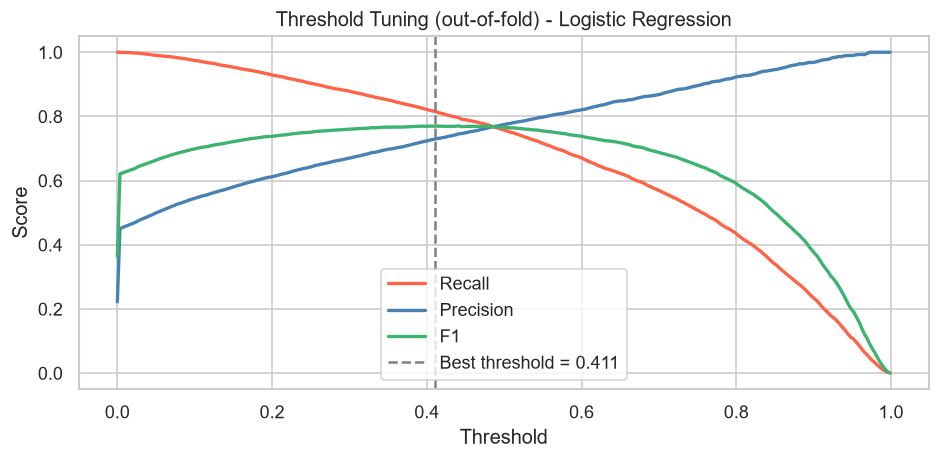

Logistic Regression: best threshold (out-of-fold) = 0.4109



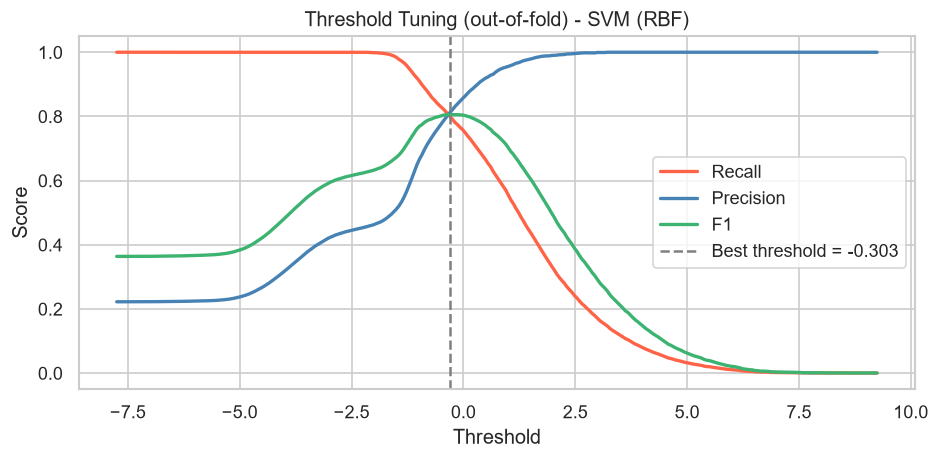

SVM (RBF): best threshold (out-of-fold) = -0.3029



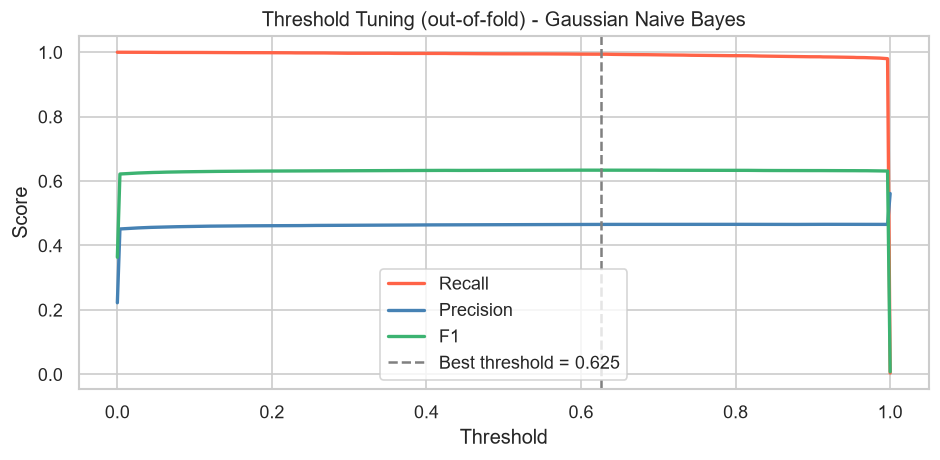

Gaussian Naive Bayes: best threshold (out-of-fold) = 0.6254



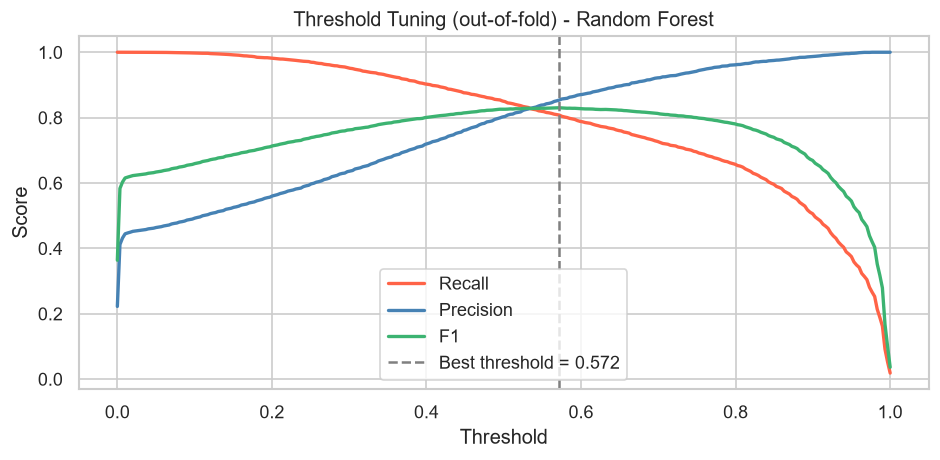

Random Forest: best threshold (out-of-fold) = 0.5719



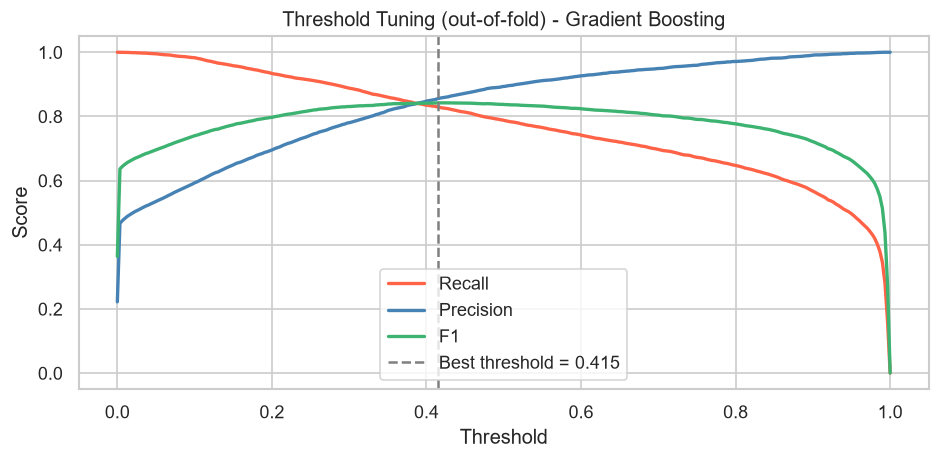

Gradient Boosting: best threshold (out-of-fold) = 0.4147



In [16]:
best_thresholds = tune_all_thresholds(models, X_train, y_train)


## 4. Test Set Evaluation - All Models

All models are evaluated on `X_test`/`y_test`. The **primary model is selected as the model with the highest test-set F1 score**.

In [17]:
results_df = evaluate_models(
    models, X_test, y_test, best_thresholds,
    sort_by=SELECTION_METRIC,
    save_path=RESULTS_DIR / 'test_results.csv',
)

print(f'Test Set Results (sorted by {SELECTION_METRIC}):')
display(style_results(results_df))

test_winner = results_df.iloc[0]
print(
    f"\nSelected primary model from the test set: {test_winner['Model']} "
    f"({SELECTION_METRIC}={test_winner[SELECTION_METRIC]:.4f})"
)
print('Saved to results/test_results.csv')


Test Set Results (sorted by F1):


,Model,Threshold,Accuracy,Balanced Accuracy,Precision,Recall,F1,PR-AUC
0,Gradient Boosting,0.4147,0.9321,0.8985,0.8538,0.8380,0.8458,0.9402
1,Random Forest,0.5719,0.9296,0.8885,0.8610,0.8145,0.8371,0.9318
2,SVM (RBF),-0.3029,0.9168,0.8772,0.8170,0.8060,0.8115,0.9084
3,Logistic Regression,0.4109,0.8954,0.8667,0.7406,0.8150,0.7760,0.8659
4,Gaussian Naive Bayes,0.6254,0.7498,0.8374,0.4702,0.9950,0.6386,0.8279



Selected primary model from the test set: Gradient Boosting (F1=0.8458)
Saved to results/test_results.csv


## 5. Confusion Matrices - All Models

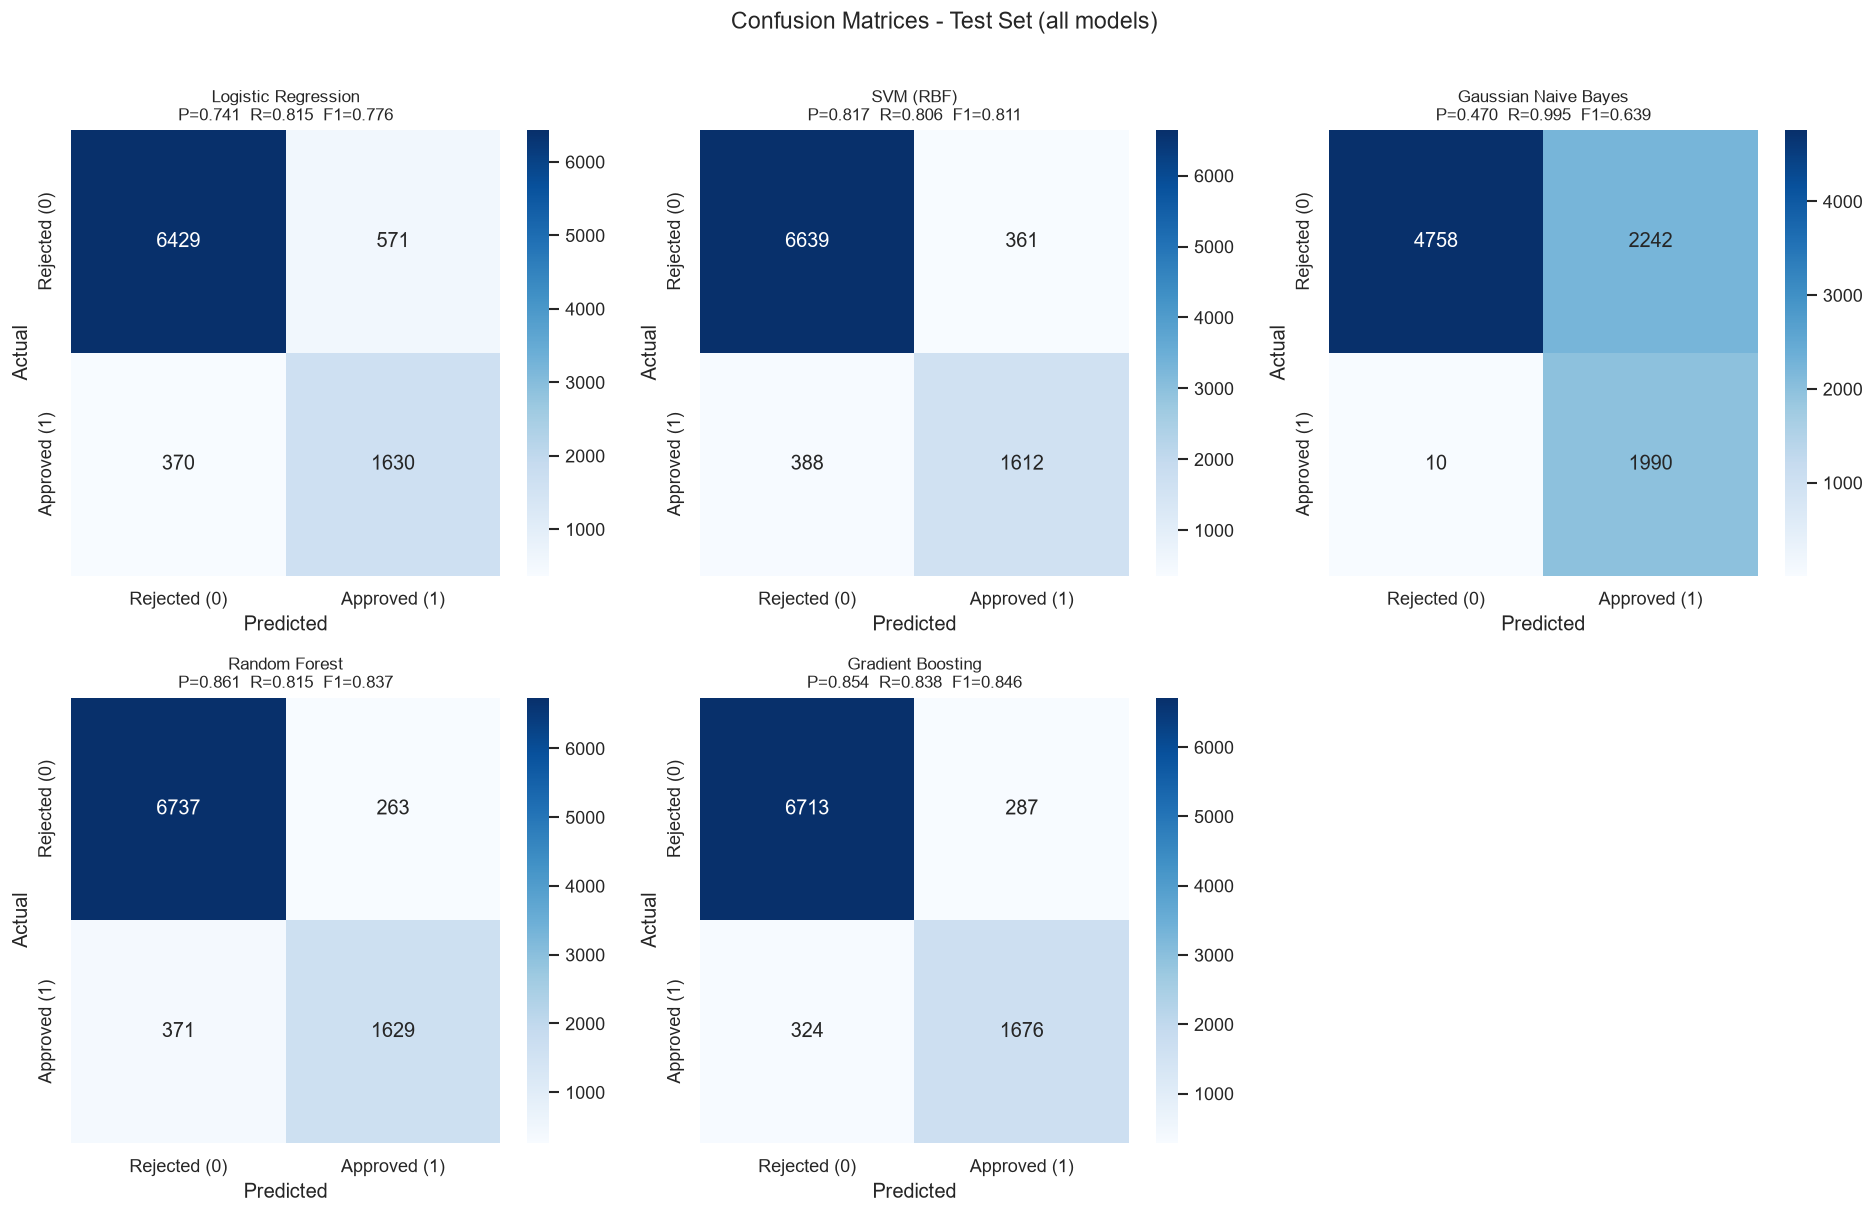

In [18]:
plot_confusion_matrices(
    models, X_test, y_test, best_thresholds,
    results_df=results_df,
    save_path=str(PLOTS_DIR / 'confusion_matrices_all.png'),
)


## 6. PR-AUC Curves - All Models

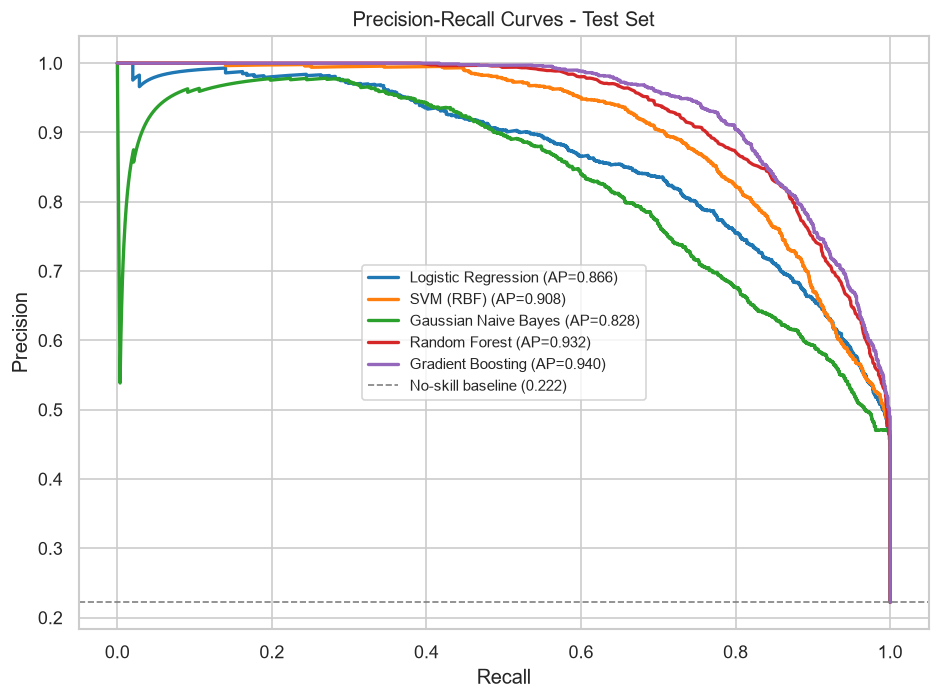

In [19]:
plot_pr_curves(
    models, X_test, y_test,
    save_path=str(PLOTS_DIR / 'pr_curves_all.png'),
)


## 7. Model Complexity, Interpretability & Computational Cost

| Model | Interpretability | Complexity | Training Cost | Notes |
|---|---|---|---|---|
| Logistic Regression | High - coefficients directly readable | Low | Fast (seconds) | Linear boundary; struggles with non-linear patterns |
| SVM (RBF) | Low - kernel space not interpretable | Medium | Slow (minutes on 36K rows) | Strong margin-based classifier; no probability output by default |
| Gaussian Naive Bayes | Medium - per-feature likelihoods | Very low | Fastest | Independence assumption violated by OHE features; high recall but low precision |
| Random Forest | Medium - feature importances available | High | Moderate (400 trees) | Robust; averages many trees; less prone to overfitting than single DT |
| Gradient Boosting | Low - ensemble of trees | High | Moderate | Sequential boosting captures complex patterns and performs good for non-linear complex features |


---
# Section 5.8: Qualitative Analysis & Interpretation
## 8. Error Analysis - Best Model

We focus error analysis on the **primary model selected by the highest test-set F1 score** from Section 5.

This is a loan-**approval** model: `loan_status` reflects the bank's historical decision, not a verified default or repayment outcome. So:
- **False Positives**: predicted Approved, but the historical decision was Rejected. 
- **False Negatives**: predicted Rejected, but the historical decision was Approved. 


In [20]:
# Select the primary model using TEST-SET performance from Section 5.
# results_df is already sorted from highest to lowest F1.
best_row = results_df.iloc[0]
best_model_name = best_row['Model']
best_selection_score = best_row[SELECTION_METRIC]

best_pipeline = models[best_model_name]
best_t        = best_thresholds[best_model_name]

X_test_reset = X_test.reset_index(drop=True)
y_test_reset = y_test.reset_index(drop=True)

scores_test = get_scores(best_pipeline, X_test_reset)
preds_test  = (scores_test >= best_t).astype(int)

masks = outcome_masks(y_test_reset, preds_test)

print(
    f'Primary model (test-set {SELECTION_METRIC}-selected): '
    f'{best_model_name} ({SELECTION_METRIC}={best_selection_score:.4f}, '
    f'threshold={best_t:.4f})'
)
print(f"True Positives  (correct approvals)  : {masks['TP'].sum():,}")
print(f"True Negatives  (correct rejections) : {masks['TN'].sum():,}")
print(f"False Positives (wrong approvals)    : {masks['FP'].sum():,}")
print(f"False Negatives (wrong rejections)   : {masks['FN'].sum():,}")


Primary model (test-set F1-selected): Gradient Boosting (F1=0.8458, threshold=0.4147)
True Positives  (correct approvals)  : 1,676
True Negatives  (correct rejections) : 6,713
False Positives (wrong approvals)    : 287
False Negatives (wrong rejections)   : 324


In [21]:
# Sample false positives - loans predicted approved but were rejected
print('=== False Positives (predicted Approved, actually Rejected) ===')
display(X_test_reset[masks['FP']].head(5))


=== False Positives (predicted Approved, actually Rejected) ===


,person_age,person_gender,person_education,person_income,person_emp_exp,person_home_ownership,loan_amnt,loan_intent,loan_int_rate,loan_percent_income,cb_person_cred_hist_length,credit_score,previous_loan_defaults_on_file
112,35.0,female,Bachelor,40861.0,11,RENT,7600.0,VENTURE,15.27,0.19,6.0,624,No
117,30.0,male,Associate,28387.0,9,RENT,3250.0,VENTURE,14.11,0.11,7.0,646,No
172,22.0,male,Associate,15013.0,0,MORTGAGE,1500.0,EDUCATION,14.84,0.10,3.0,688,No
202,26.0,male,Master,157279.0,3,MORTGAGE,35000.0,PERSONAL,18.25,0.22,4.0,693,No
203,23.0,male,Associate,59480.0,4,RENT,4800.0,EDUCATION,11.36,0.08,4.0,577,No


In [22]:
# Sample false negatives - loans predicted rejected but were approved
print('=== False Negatives (predicted Rejected, actually Approved) ===')
display(X_test_reset[masks['FN']].head(5))


=== False Negatives (predicted Rejected, actually Approved) ===


,person_age,person_gender,person_education,person_income,person_emp_exp,person_home_ownership,loan_amnt,loan_intent,loan_int_rate,loan_percent_income,cb_person_cred_hist_length,credit_score,previous_loan_defaults_on_file
74,24.0,female,High School,43833.0,5,RENT,8000.0,PERSONAL,12.12,0.18,4.0,658,No
110,26.0,male,Bachelor,140055.0,6,MORTGAGE,5000.0,VENTURE,11.01,0.04,3.0,653,No
145,24.0,female,Bachelor,85978.0,3,MORTGAGE,5000.0,EDUCATION,10.39,0.06,2.0,631,No
154,23.0,female,Associate,68223.0,1,MORTGAGE,15000.0,PERSONAL,11.26,0.22,2.0,607,No
165,25.0,female,Bachelor,83753.0,0,RENT,8500.0,HOMEIMPROVEMENT,6.92,0.10,4.0,644,No


### 8.1 TP, TN, FP, FN Profile Analysis

Compare the average feature values of false positives, true positives, false negatives and true negatives to analyze underlying patterns.


In [23]:
numeric_cols = ['person_age', 'person_income', 'person_emp_exp', 'loan_amnt',
                'loan_int_rate', 'loan_percent_income', 'cb_person_cred_hist_length', 'credit_score']

profile_df = outcome_profile(X_test_reset, masks, numeric_cols)
print('Mean feature values by prediction outcome:')
display(profile_df)


Mean feature values by prediction outcome:


,True Positive,False Positive,True Negative,False Negative
person_age,27.36,28.14,27.85,27.91
person_income,55914.97,70841.76,86023.37,71162.16
person_emp_exp,5.03,5.76,5.52,5.41
loan_amnt,11404.18,8821.00,9205.89,8232.29
loan_int_rate,13.12,13.34,10.34,11.00
loan_percent_income,0.22,0.14,0.12,0.13
cb_person_cred_hist_length,5.78,6.03,5.91,5.84
credit_score,626.33,632.27,633.19,648.74


## 9. Feature Importance Interpretation

In [24]:
with open(MODELS_DIR / 'feature_names.json') as f:
    feature_names = json.load(f)


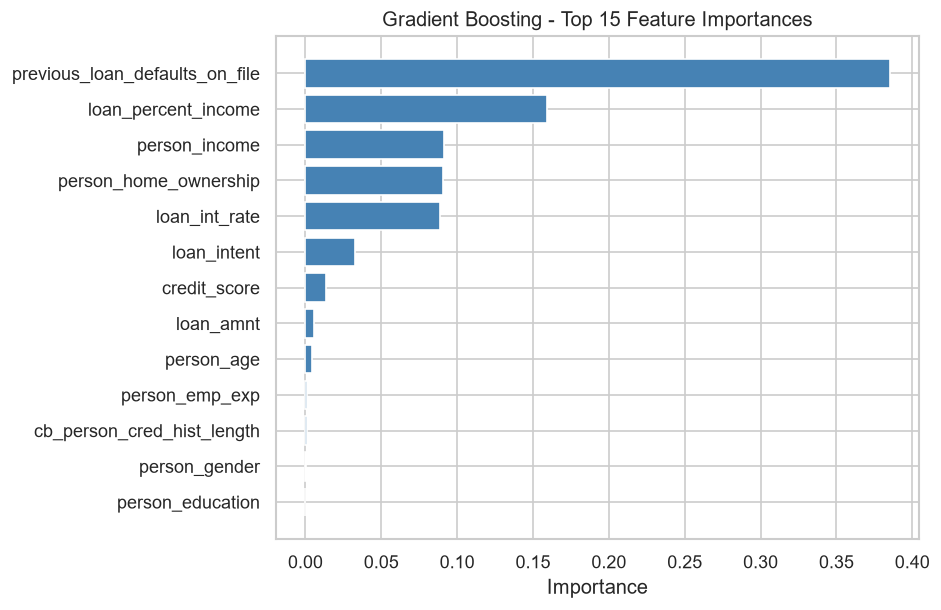

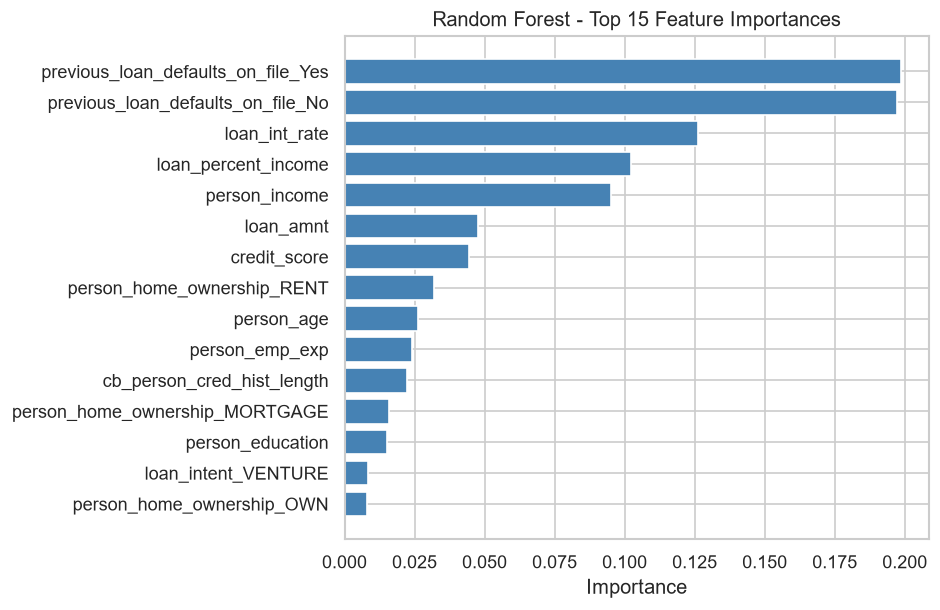

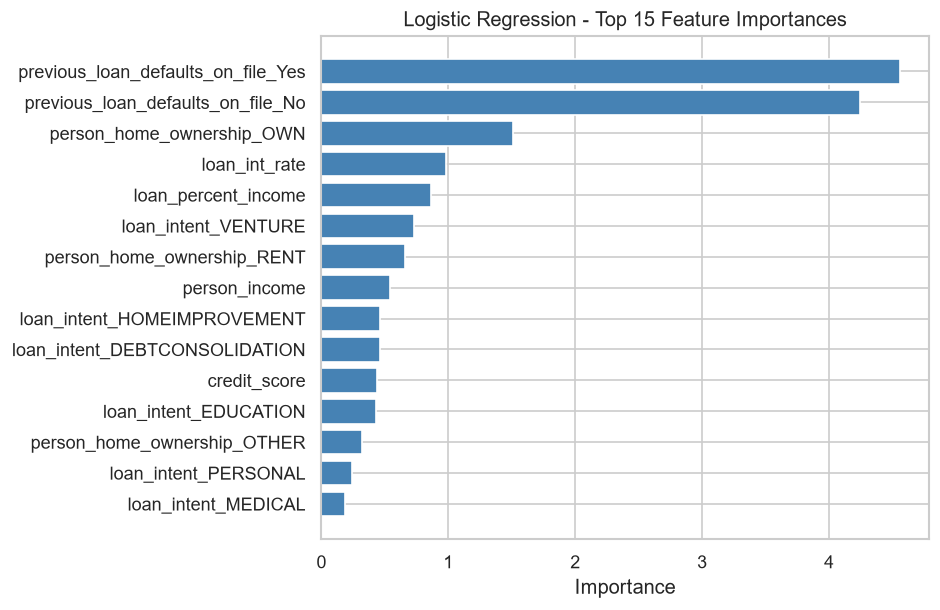

In [25]:
for name in ['Gradient Boosting', 'Random Forest', 'Logistic Regression']:
    slug = name.lower().replace(' ', '_').replace('(', '').replace(')', '')
    plot_importances(
        models[name], name, feature_names,
        X_eval=X_test, y_eval=y_test,   # used only for GB's permutation-importance fallback
        save_path=str(PLOTS_DIR / f'importance_{slug}.png')
    )


## 10. Why Some Models Performed Better Than Others

**Gradient Boosting** likely performed best because it builds trees sequentially: each tree corrects the errors of the previous one. This lets it capture complex, non-linear interactions between features (e.g. the interaction between `credit_score`, `loan_percent_income`, and `previous_loan_defaults_on_file`) that a linear model can't represent as directly. (The permutation-importance results above are consistent with this, but performance alone doesn't prove this is *the* mechanism: regularisation strength and how each model handles the categorical encoding likely also play a role.)

**Random Forest** performed second-best. It averages many independent trees (bagging), which reduces variance compared to a single decision tree. It trails Gradient Boosting because each tree is built independently rather than correctively.

**SVM (RBF)** performed reasonably but was the slowest to train. The RBF kernel maps data to a higher-dimensional space to find a margin, and it is sensitive to feature scaling. Its `decision_function` score is not a calibrated probability, which limits how the score can be *interpreted* (e.g. as "70% likely approved") - it does not prevent threshold tuning, since the threshold is chosen directly on that score (Section 4).

**Logistic Regression** is a linear model. It can only draw a straight decision boundary in the feature space. The loan approval decision is not linearly separable, which is reflected in its lower test-set classification performance. It is, however, the most interpretable: coefficients directly show which features push toward approval.

**Gaussian Naive Bayes** performs poorly in precision despite achieving high recall. This is because it assumes all features are independent, which is violated here. The one-hot encoded categorical variables (e.g. `loan_intent`) are by construction correlated with each other. As a result, the model overestimates the posterior probability of approval.

## 11. Final Comparison Table

In [28]:
print('Final Test Set Results:')
print(results_df.to_string(index=False))

Final Test Set Results:
               Model  Threshold  Accuracy  Balanced Accuracy  Precision  Recall       F1   PR-AUC
   Gradient Boosting     0.4147  0.932111           0.898500   0.853795  0.8380 0.845824 0.940169
       Random Forest     0.5719  0.929556           0.888464   0.860994  0.8145 0.837102 0.931812
           SVM (RBF)    -0.3029  0.916778           0.877214   0.817030  0.8060 0.811477 0.908397
 Logistic Regression     0.4109  0.895444           0.866714   0.740572  0.8150 0.776006 0.865948
Gaussian Naive Bayes     0.6254  0.749778           0.837357   0.470227  0.9950 0.638639 0.827950


## 12. Feature-Set Experiments Evaluation

Section 8 of `03_model_training` searched alternate feature sets on **cross-validation F1** only and copied the CV-winners to `best_demo_model_*.pkl`.

So in this section, we re-score the saved feature-set pipelines on the test set with the identical threshold-tuning + metrics path. We only report the CV-selected variants and we are **not** re-searching on test set, so the selection bias on the test number stays negligible.

Feature sets:
- `WITHOUT_prevdef`: drops `previous_loan_defaults_on_file`
- `WITH_prevdef_eng` / `WITHOUT_prevdef_eng`: adds the two engineered ratio features, with / without `prevdef`

**Splits:** `prevdef` is dropped *inside* the pipeline preprocessor, so `WITHOUT_prevdef` reuses the base test set. The engineered sets add columns at load time, so they need their own `load_data(..., add_engineered=True)` split (same `SEED` → same rows, extra columns).

### 12.1 Build the Engineered Test Split

In [29]:
from evaluate import load_feature_set_models

# Engineered feature sets carry extra columns -> rebuild the split with add_engineered=True.
# Same SEED and same rows as Section 1, so test instances line up one-to-one with the base split.
df_eng = load_data(DATA_PATH, add_engineered=True)
X_train_eng, X_test_eng, y_train_eng, y_test_eng = split_data(df_eng)

assert len(y_test_eng) == len(y_test), 'engineered split row count differs from the base split'
assert (np.asarray(y_test_eng) == np.asarray(y_test)).all(), (
    'engineered split rows differ from base - engineered features likely dropped rows '
    '(NaN/inf from a ratio); comparison would not be apples-to-apples'
)

print(f'Base test      : {X_test.shape[1]} cols')
print(f'Engineered test: {X_test_eng.shape[1]} cols  (+{X_test_eng.shape[1] - X_test.shape[1]} engineered)')

Base test      : 13 cols
Engineered test: 15 cols  (+2 engineered)


### 12.2 Tune Thresholds & Score each feature set on the Test Set

In [30]:
# (train_X, train_y) tune the threshold out-of-fold
# (test_X, test_y) are scored.
FEATURE_SETS = {
    'WITHOUT_prevdef':     (X_train,     y_train,     X_test,     y_test),
    'WITH_prevdef_eng':    (X_train_eng, y_train_eng, X_test_eng, y_test_eng),
    'WITHOUT_prevdef_eng': (X_train_eng, y_train_eng, X_test_eng, y_test_eng),
}

fs_frames = []
for tag, (Xtr, ytr, Xte, yte) in FEATURE_SETS.items():
    print(f'=== {tag} ===')
    fs_models = load_feature_set_models(tag)
    if not fs_models:
        print('  no pickles found - run Section 8 of 03_model_training first.\n')
        continue
    fs_thr = tune_all_thresholds(fs_models, Xtr, ytr, plot=False, verbose=False)  # OOF on matching train
    fs_res = evaluate_models(fs_models, Xte, yte, fs_thr)
    fs_res.insert(1, 'Feature Set', tag)
    fs_frames.append(fs_res)
    print()

if not fs_frames:
    raise FileNotFoundError('No feature-set pickles found - run Section 8 of 03_model_training first.')

feature_set_test = pd.concat(fs_frames, ignore_index=True)
feature_set_test.to_csv(RESULTS_DIR / 'feature_set_test_results.csv', index=False)
print('Saved -> results/feature_set_test_results.csv')
display(style_results(feature_set_test))

=== WITHOUT_prevdef ===
Loaded: LogisticRegression_WITHOUT_prevdef.pkl  ->  Logistic Regression
Loaded: RandomForest_WITHOUT_prevdef.pkl  ->  Random Forest
Loaded: GradientBoosting_WITHOUT_prevdef.pkl  ->  Gradient Boosting
Loaded: GaussianNB_WITHOUT_prevdef.pkl  ->  Gaussian Naive Bayes

=== WITH_prevdef_eng ===
Loaded: LogisticRegression_WITH_prevdef_eng.pkl  ->  Logistic Regression
Loaded: RandomForest_WITH_prevdef_eng.pkl  ->  Random Forest
Loaded: GradientBoosting_WITH_prevdef_eng.pkl  ->  Gradient Boosting
Loaded: GaussianNB_WITH_prevdef_eng.pkl  ->  Gaussian Naive Bayes

=== WITHOUT_prevdef_eng ===
Loaded: LogisticRegression_WITHOUT_prevdef_eng.pkl  ->  Logistic Regression
Loaded: RandomForest_WITHOUT_prevdef_eng.pkl  ->  Random Forest
Loaded: GradientBoosting_WITHOUT_prevdef_eng.pkl  ->  Gradient Boosting
Loaded: GaussianNB_WITHOUT_prevdef_eng.pkl  ->  Gaussian Naive Bayes

Saved -> results/feature_set_test_results.csv


,Model,Feature Set,Threshold,Accuracy,Balanced Accuracy,Precision,Recall,F1,PR-AUC
0,Gradient Boosting,WITHOUT_prevdef,0.4214,0.9122,0.8375,0.8777,0.7030,0.7807,0.8749
1,Random Forest,WITHOUT_prevdef,0.5485,0.9081,0.8341,0.8596,0.7010,0.7722,0.8667
2,Logistic Regression,WITHOUT_prevdef,0.6141,0.8274,0.7794,0.5961,0.6930,0.6409,0.7029
3,Gaussian Naive Bayes,WITHOUT_prevdef,0.5853,0.8313,0.7539,0.6220,0.6145,0.6182,0.6708
4,Gradient Boosting,WITH_prevdef_eng,0.4281,0.9338,0.8974,0.8649,0.8320,0.8481,0.9393
5,Random Forest,WITH_prevdef_eng,0.5619,0.9288,0.8899,0.8537,0.8200,0.8365,0.9314
6,Logistic Regression,WITH_prevdef_eng,0.4175,0.8964,0.8668,0.7443,0.8135,0.7774,0.8655
7,Gaussian Naive Bayes,WITH_prevdef_eng,0.6321,0.7500,0.8377,0.4705,0.9955,0.6390,0.8281
8,Gradient Boosting,WITHOUT_prevdef_eng,0.3679,0.9080,0.8432,0.8379,0.7265,0.7783,0.8754
9,Random Forest,WITHOUT_prevdef_eng,0.5452,0.9089,0.8329,0.8678,0.6960,0.7725,0.8630


### 12.3 Combined Comparison: Base vs Feature-set variants

In [31]:
base_tagged = results_df.copy()
base_tagged.insert(1, 'Feature Set', 'BASE_with_prevdef')

all_results = pd.concat([base_tagged, feature_set_test], ignore_index=True)

# F1 by model x feature set (NaN where a model wasn't run for that set, e.g. SVM).
pivot_f1 = all_results.pivot_table(index='Model', columns='Feature Set', values=SELECTION_METRIC).round(4)
print(f'Test-set {SELECTION_METRIC} by model x feature set:')
display(pivot_f1)

Test-set F1 by model x feature set:


Feature Set,BASE_with_prevdef,WITHOUT_prevdef,WITHOUT_prevdef_eng,WITH_prevdef_eng
Model,,,,
Gaussian Naive Bayes,0.6386,0.6182,0.6211,0.6390
Gradient Boosting,0.8458,0.7807,0.7783,0.8481
Logistic Regression,0.7760,0.6409,0.6358,0.7774
Random Forest,0.8371,0.7722,0.7725,0.8365
SVM (RBF),0.8115,NaN,NaN,NaN


### 12.4 Analysis

From the comparative analysis, it can be deduced that:

- `Previous_loan_defaults_on_file` is the dominant feature. Dropping it lowers test F1-score for every model. Linear Regression takes the biggest hit (LR −0.135), decision trees also degrade (GB/RF ≈ −0.065), Gaussian Naive Bayes barely moves, so treat it as a hard dependency at inference.

- Feature Engineered ratios do not improve the model. With prevdef, adding the engineered features moves F1 by ≤0.002 (noise); without prevdef, they don't recover the loss either. Therefore, the extra preprocessing does not impact our model's performance and is redundant.

- Model ranking is stable: GB ≈ RF > SVM > LR > GNB across all feature sets.

In [32]:
# Best variant per feature set, and the overall test winner.
def _best_of(fs):
    sub = all_results[all_results['Feature Set'] == fs]
    if sub.empty:
        return None
    r = sub.loc[sub[SELECTION_METRIC].idxmax()]
    return str(r['Model']), float(r[SELECTION_METRIC])

base_best = _best_of('BASE_with_prevdef')
print(f"Base (with prevdef)          : {base_best[0]:22s} F1={base_best[1]:.4f}")

for fs in ['WITHOUT_prevdef', 'WITH_prevdef_eng', 'WITHOUT_prevdef_eng']:
    b = _best_of(fs)
    if b is None:
        print(f"{fs:28s} : (no models)")
        continue
    d = b[1] - base_best[1]
    verdict = 'better than' if d > 1e-4 else ('~ same as' if abs(d) <= 1e-4 else 'worse than')
    print(f"{fs:28s} : {b[0]:22s} F1={b[1]:.4f}  ({d:+.4f}, {verdict} base)")

winner = all_results.loc[all_results[SELECTION_METRIC].idxmax()]
print(f"\nBest on TEST overall: {winner['Model']} / {winner['Feature Set']}  (F1={winner[SELECTION_METRIC]:.4f})")

Base (with prevdef)          : Gradient Boosting      F1=0.8458
WITHOUT_prevdef              : Gradient Boosting      F1=0.7807  (-0.0651, worse than base)
WITH_prevdef_eng             : Gradient Boosting      F1=0.8481  (+0.0023, better than base)
WITHOUT_prevdef_eng          : Gradient Boosting      F1=0.7783  (-0.0676, worse than base)

Best on TEST overall: Gradient Boosting / WITH_prevdef_eng  (F1=0.8481)


Among all models, the **Gadrient Boosting** trained on base features (with prevdef) is chosen as the **best model**. The top cell (GB with prevdef and engineered feature = 0.8481) beats GB base (0.8458) by +0.0023. This value is within noise, so we pick the simpler model without extra engineered features.